# 12 - Evaluate + Test UI: Pest Classifier (YOLOv8)

This notebook evaluates the trained YOLOv8 classification model on the test dataset split and launches an interactive Gradio interface for live predictions.

## Imports & Configuration

In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from ultralytics import YOLO
import gradio as gr

# Current notebook directory
NOTEBOOK_DIR = Path.cwd()

# Dataset directory
OUT_DIR = NOTEBOOK_DIR / "pest_dataset"

# Models directory
MODELS_DIR = NOTEBOOK_DIR / "models" / "pest_classifier"

# Final model path
FINAL_MODEL_PATH = MODELS_DIR / "pest_classifier.pt"

print(f"Dataset location : {OUT_DIR.resolve()}")
print(f"Final model path : {FINAL_MODEL_PATH.resolve()}")


c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset location : Z:\Projects\Smart-Farming\Crop Identification\notebooks\pest_dataset
Final model path : Z:\Projects\Smart-Farming\Crop Identification\notebooks\models\pest_classifier\pest_classifier.pt


## Load and verify model

In [2]:
# ============================================================
# LOAD MODEL
# ============================================================

if not FINAL_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"\nFinal model weights were not found at:\n"
        f"{FINAL_MODEL_PATH}\n\n"
        f"Please train the model first using notebook 11."
    )

print("Loading trained model...")
model = YOLO(str(FINAL_MODEL_PATH))
print("Model loaded successfully!")
print(f"Classes: {model.names}")


Loading trained model...
Model loaded successfully!
Classes: {0: 'A', 1: 'AW', 2: 'LM', 3: 'SM'}


## Evaluate on Test Split

Evaluating on test set classes: ['A', 'AW', 'LM', 'SM']

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A      1.000     0.900     0.947        10
          AW      1.000     1.000     1.000         6
          LM      0.983     0.983     0.983        59
          SM      0.875     1.000     0.933         7

    accuracy                          0.976        82
   macro avg      0.965     0.971     0.966        82
weighted avg      0.977     0.976     0.976        82

Macro-F1: 0.9659


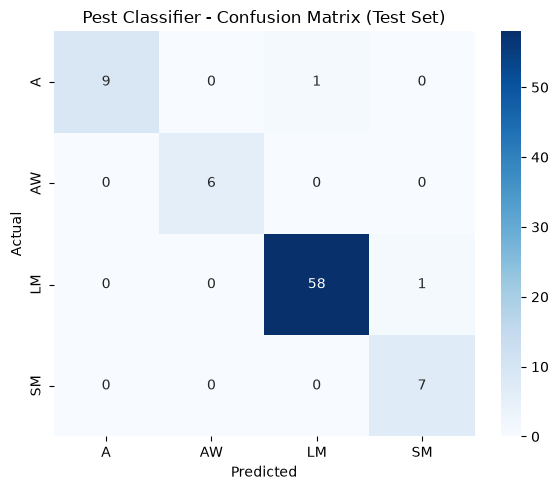

Saved confusion matrix to: Z:\Projects\Smart-Farming\Crop Identification\notebooks\confusion_matrix_pest.png


In [3]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

def evaluate_test_set(model):
    test_dir = OUT_DIR / "test"
    
    if not test_dir.exists():
        raise FileNotFoundError(
            f"\nTest dataset split not found at:\n"
            f"{test_dir}"
        )
        
    classes = sorted([d.name for d in test_dir.iterdir() if d.is_dir()])
    print(f"Evaluating on test set classes: {classes}")

    y_true, y_pred = [], []
    for class_name in classes:
        class_folder = test_dir / class_name
        for img_path in class_folder.iterdir():
            # Run prediction
            result = model.predict(str(img_path), verbose=False)[0]
            pred_idx = int(result.probs.top1)
            pred_class = result.names[pred_idx]
            
            y_true.append(class_name)
            y_pred.append(pred_class)

    print("\n" + "=" * 50)
    print("CLASSIFICATION REPORT")
    print("=" * 50)
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))
    
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"Macro-F1: {macro_f1:.4f}")
    
    # Confusion Matrix
    cm_labels = sorted(list(set(y_true) | set(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=cm_labels)
    
    plt.figure(figsize=(max(6, len(cm_labels)), max(5, len(cm_labels) * 0.8)))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        xticklabels=cm_labels, 
        yticklabels=cm_labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Pest Classifier - Confusion Matrix (Test Set)")
    plt.tight_layout()
    
    cm_path = NOTEBOOK_DIR / "confusion_matrix_pest.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()
    print(f"Saved confusion matrix to: {cm_path.resolve()}")
    
    return macro_f1

macro_f1 = evaluate_test_set(model)


## Gradio Interactive UI

In [4]:
# ============================================================
# GRADIO UI FOR INTERACTIVE TESTING
# ============================================================

def build_predict_fn(model):
    def predict(image_rgb):
        if image_rgb is None:
            return {}
        result = model.predict(image_rgb, verbose=False)[0]
        probs = result.probs.data.cpu().numpy()
        names = result.names
        return {names[i]: float(probs[i]) for i in range(len(probs))}
    return predict

def launch_ui(model):
    predict_fn = build_predict_fn(model)
    
    demo = gr.Interface(
        fn=predict_fn,
        inputs=gr.Image(type="numpy", label="Drag & drop a leaf/pest-damage photo here"),
        outputs=gr.Label(num_top_classes=5, label="Pest Prediction"),
        title="Smart Farming - Pest Symptom Classifier (Test UI)",
        description=(
            "Upload or drag & drop a photo showing possible pest damage. "
            "Note: this is a CLASSIFIER (what pest is likely present), not "
            "a detector -- it won't draw a box around the insect itself. "
            "Trained on a small, imbalanced dataset -- treat low-confidence or "
            "borderline predictions with caution."
        ),
    )
    demo.launch()

print("Launching Gradio test UI...")
launch_ui(model)


Launching Gradio test UI...
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
